## Reconstruction Pipeline Test 


In [1]:
!pip install -q opencv-python-headless matplotlib
print("Done") 

Done


In [2]:
!pip install -q projectaria-tools

# This downloads a small free sample sequence from DTC
!git clone --quiet https://github.com/facebookresearch/hot3d.git
%cd hot3d/hot3d
!pip install -q projectaria_tools torch requests



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 77.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 MB 26.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 116.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.2 MB/s eta 0:00:00
/content/hot3d/hot3d


### Loading 3d object mesh from trimesh for testing 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 12.6 MB/s eta 0:00:00 0:00:01
Vertices : 8
Faces    : 12
Watertight: True
Volume   : 0.2400 m³


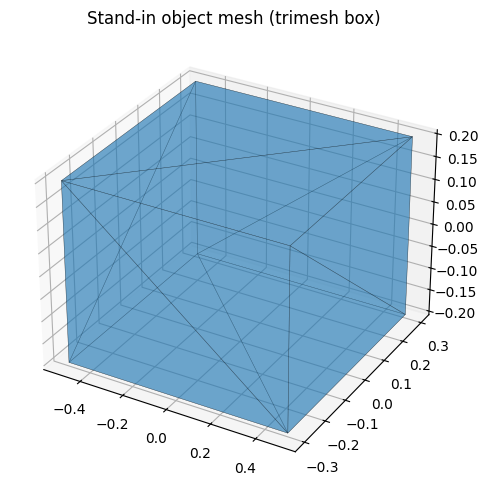

In [8]:
# Cell 3 — Verify mesh I/O with trimesh (no download required)
!pip install -q trimesh

import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

mesh = trimesh.creation.box(extents=[1.0, 0.6, 0.4])

print(f"Vertices : {len(mesh.vertices)}")
print(f"Faces    : {len(mesh.faces)}")
print(f"Watertight: {mesh.is_watertight}")
print(f"Volume   : {mesh.volume:.4f} m³")

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
poly = Poly3DCollection(mesh.vertices[mesh.faces], alpha=0.4, edgecolor='k', linewidth=0.3)
ax.add_collection3d(poly)
ax.auto_scale_xyz(*[[mesh.bounds[0][i], mesh.bounds[1][i]] for i in range(3)])
ax.set_title("Stand-in object mesh (trimesh box)")
plt.tight_layout()
plt.show()


In [ ]:
# Cell 4 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


### Extract frames from video

In [18]:
# Cell 5 — Extract frames directly with ffmpeg (no conversion needed)
import os

video_path = "/content/drive/MyDrive/hydroflaskgreen.MOV"
output_dir = "/content/frames"
os.makedirs(output_dir, exist_ok=True)

# Extract 1 frame per second directly from .mov
!ffmpeg -i "{video_path}" -vf fps=1 "{output_dir}/frame_%05d.jpg" -y -loglevel error

saved = len(os.listdir(output_dir))
print(f"Saved {saved} frames to {output_dir}")


Saved 14 frames to /content/frames


### Frames preview

Frames: ['frame_00001.jpg', 'frame_00002.jpg', 'frame_00003.jpg'] ... frame_00014.jpg


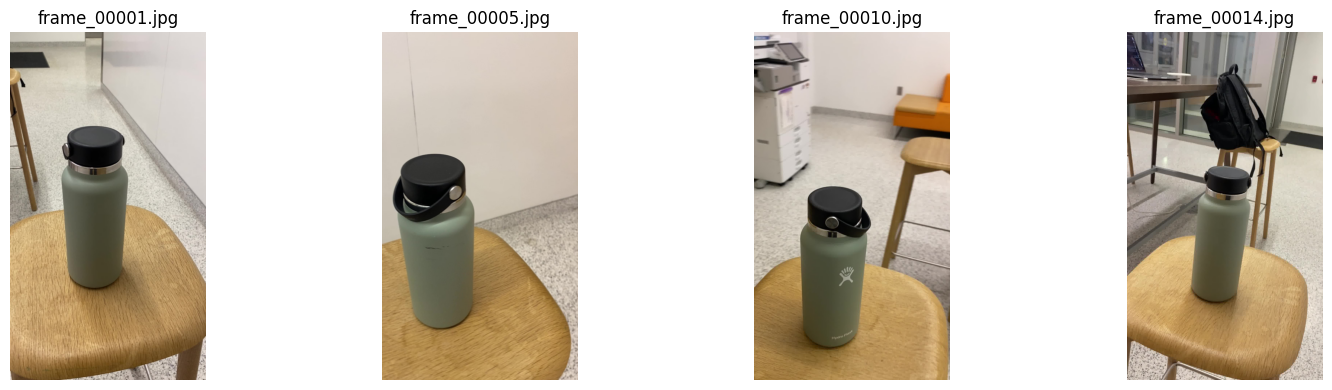

In [19]:
# Cell 6 — Preview extracted frames
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

frame_files = sorted(os.listdir("/content/frames"))
print(f"Frames: {frame_files[:3]} ... {frame_files[-1]}")

# Show 4 evenly spaced frames
indices = [0, len(frame_files)//3, 2*len(frame_files)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    img = mpimg.imread(f"/content/frames/{frame_files[i]}")
    ax.imshow(img)
    ax.set_title(frame_files[i])
    ax.axis("off")
plt.tight_layout()
plt.show()


#### Re extracting for 5fps instead

In [21]:
# Cell 7 — Re-extract at 5fps for denser coverage
import os, shutil

output_dir = "/content/frames"
shutil.rmtree(output_dir)
os.makedirs(output_dir)

video_path = "/content/drive/MyDrive/hydroflaskgreen.MOV"
!ffmpeg -i "{video_path}" -vf fps=5 "{output_dir}/frame_%05d.jpg" -y -loglevel error

saved = len(os.listdir(output_dir))
print(f"Saved {saved} frames")


Saved 70 frames


### COLMAP

In [23]:
# Cell 8 — Install COLMAP
!apt-get install -qq colmap
!colmap -h 2>&1 | head -3


Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd64.deb ...
Unpacking libevdev2:amd64 (1.12.1+dfsg-1) ...
Selecting previously unselected package libmtdev1:amd64.
Preparing to unpack .../03-libmtdev1_1.1.6-1build4_amd64.deb ...
Unpacking libmtdev1:amd64 (1.1.6-1build4) ...
Selecting previously unselected package libgudev-1.0-0:amd64.
Preparing to unpack .../04-libgudev-1.0-0_1%3a237-2build1_amd64.deb ...
Unpacking libgudev-1.0-0:amd6

### COLMAP Structure from Motion pipeline
Feature extraction -> matching -> sparse reconstruction pipeline from COLMAP. 

In [24]:
# Cell 9 — Run COLMAP SfM to get camera poses
import os

images_dir = "/content/frames"
colmap_dir = "/content/colmap"
db_path    = f"{colmap_dir}/database.db"
sparse_dir = f"{colmap_dir}/sparse"

os.makedirs(sparse_dir, exist_ok=True)

# Step 1: Feature extraction
!colmap feature_extractor \
    --database_path {db_path} \
    --image_path {images_dir} \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0

# Step 2: Feature matching
!colmap exhaustive_matcher \
    --database_path {db_path} \
    --SiftMatching.use_gpu 0

# Step 3: Sparse reconstruction
!colmap mapper \
    --database_path {db_path} \
    --image_path {images_dir} \
    --output_path {sparse_dir}

print("\nDone. Sparse models found:", os.listdir(sparse_dir))



Feature extraction

Processed file [1/70]
  Name:            frame_00006.jpg
  Dimensions:      1080 x 1920
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2304.00px
  Features:        4786
Processed file [2/70]
  Name:            frame_00004.jpg
  Dimensions:      1080 x 1920
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2304.00px
  Features:        9025
Processed file [3/70]
  Name:            frame_00007.jpg
  Dimensions:      1080 x 1920
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2304.00px
  Features:        10103
Processed file [4/70]
  Name:            frame_00008.jpg
  Dimensions:      1080 x 1920
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2304.00px
  Features:        10622
Processed file [5/70]
  Name:            frame_00005.jpg
  Dimensions:      1080 x 1920
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2304.00px
  Features:        11301
Processed file [6/70]
  Name:            frame_00001.jpg
  Dimensions:      1080 

#### Final checks of reconstruction quality

In [25]:
# Cell 10 — Check sparse reconstruction quality
import subprocess, os

sparse_path = "/content/colmap/sparse/0"

result = subprocess.run(
    ["colmap", "model_analyzer", "--path", sparse_path],
    capture_output=True, text=True
)
print(result.stdout)


Cameras: 1
Images: 70
Registered images: 70
Points: 12130
Observations: 60859
Mean track length: 5.017230
Mean observations per image: 869.414286
Mean reprojection error: 0.907020px



### Prep files for 3d gaussian splatting

In [26]:
# Cell 11 — Set up 3DGS input folder structure
import os, shutil

gs_dir = "/content/gaussian-splatting-data"
images_dst = f"{gs_dir}/input"
sparse_dst = f"{gs_dir}/sparse/0"

os.makedirs(images_dst, exist_ok=True)
os.makedirs(sparse_dst, exist_ok=True)

# Copy frames
for f in os.listdir("/content/frames"):
    shutil.copy(f"/content/frames/{f}", f"{images_dst}/{f}")

# Copy COLMAP sparse model
for f in os.listdir("/content/colmap/sparse/0"):
    shutil.copy(f"/content/colmap/sparse/0/{f}", f"{sparse_dst}/{f}")

print("input/ frames:", len(os.listdir(images_dst)))
print("sparse/0/ files:", os.listdir(sparse_dst))


input/ frames: 70
sparse/0/ files: ['images.bin', 'cameras.bin', 'points3D.bin', 'project.ini']


### Install 3d gaussian splatting

In [27]:
# Cell 12 — Clone and install 3D Gaussian Splatting
import os
os.chdir("/content")

!git clone --quiet --recursive https://github.com/graphdeco-inria/gaussian-splatting
os.chdir("/content/gaussian-splatting")

!pip install -q plyfile tqdm
!pip install -q submodules/diff-gaussian-rasterization
!pip install -q submodules/simple-knn

print("Install complete")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Install complete


### Training 3D Gaussian Splatting

##### 1.) First undistort images to PINHOLE format

In [ ]:
# Cell 13 — Undistort images to PINHOLE format
import os

os.makedirs("/content/colmap_undistorted", exist_ok=True)

!colmap image_undistorter \
    --image_path /content/frames \
    --input_path /content/colmap/sparse/0 \
    --output_path /content/colmap_undistorted \
    --output_type COLMAP

print("Done. Contents:", os.listdir("/content/colmap_undistorted"))



Reading reconstruction

 => Reconstruction with 70 images and 12130 points

Image undistortion

Undistorting image [1/70]
Undistorting image [2/70]
Undistorting image [3/70]
Undistorting image [4/70]
Undistorting image [5/70]
Undistorting image [6/70]
Undistorting image [7/70]
Undistorting image [8/70]
Undistorting image [9/70]
Undistorting image [10/70]
Undistorting image [11/70]
Undistorting image [12/70]
Undistorting image [13/70]
Undistorting image [14/70]
Undistorting image [15/70]
Undistorting image [16/70]
Undistorting image [17/70]
Undistorting image [18/70]
Undistorting image [19/70]
Undistorting image [20/70]
Undistorting image [21/70]
Undistorting image [22/70]
Undistorting image [23/70]
Undistorting image [24/70]
Undistorting image [25/70]
Undistorting image [26/70]
Undistorting image [27/70]
Undistorting image [28/70]
Undistorting image [29/70]
Undistorting image [30/70]
Undistorting image [31/70]
Undistorting image [32/70]
Undistorting image [33/70]
Undistorting image [3

### Train 3DGS on undistorted data


In [ ]:
# Cell 14 — Train 3DGS on undistorted data
import os
os.chdir("/content/gaussian-splatting")

!python train.py \
    -s /content/colmap_undistorted \
    -m /content/gs_output \
    --iterations 7000 \
    --save_iterations 7000


2026-04-16 00:46:19.368363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776300379.390610   18836 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776300379.398092   18836 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776300379.416999   18836 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776300379.417022   18836 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776300379.417025   18836 computation_placer.cc:177] computation placer alr

### Training results 

- L1 = 0.012270279973745347  (clean convergence)
- PSNR (peak signal to noise ratio) = 33.74dB this is Excellent >30 dB. 


### Render Video from Trained Model for viewing reconstruction

In [ ]:
# Cell 15 — Render novel views from trained model
import os
os.chdir("/content/gaussian-splatting")

!python render.py \
    -m /content/gs_output \
    --skip_test

print("Renders saved to:", os.listdir("/content/gs_output/train"))


Looking for config file in /content/gs_output/cfg_args
Config file found: /content/gs_output/cfg_args
Rendering /content/gs_output
Loading trained model at iteration 7000 [16/04 01:07:37]
Reading camera 70/70 [16/04 01:07:38]
Loading Training Cameras [16/04 01:07:38]
Loading Test Cameras [16/04 01:07:40]
Rendering progress: 100% 70/70 [01:05<00:00,  1.07it/s]
Renders saved to: ['ours_7000']


### Visualize Rendered Video of Reconstruction

Total rendered frames: 70


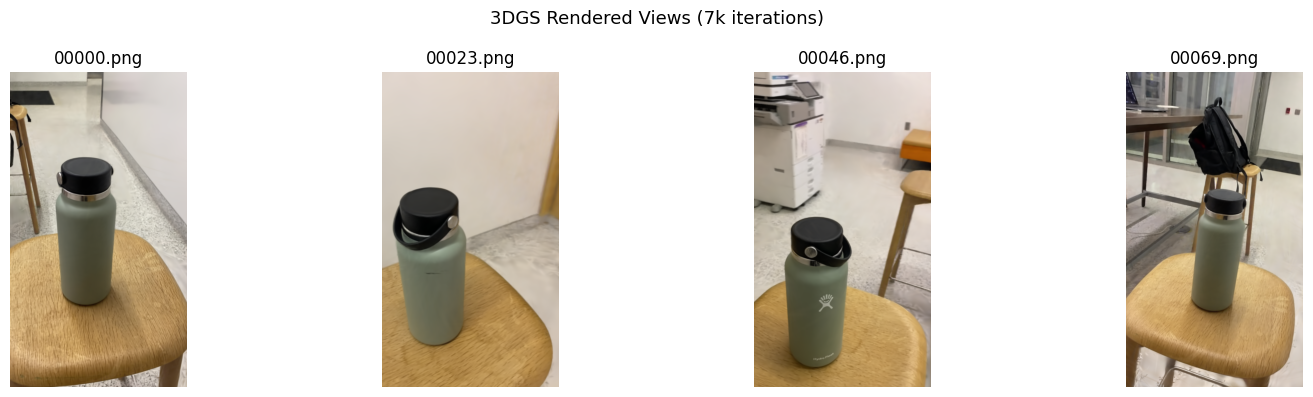

In [ ]:
# Cell 16 — Preview rendered frames
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

render_dir = "/content/gs_output/train/ours_7000/renders"
frames = sorted(os.listdir(render_dir))
print(f"Total rendered frames: {len(frames)}")

# Show 4 evenly spaced renders
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    img = mpimg.imread(f"{render_dir}/{frames[i]}")
    ax.imshow(img)
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle("3DGS Rendered Views (7k iterations)", fontsize=13)
plt.tight_layout()
plt.show()


### Compare original vs render

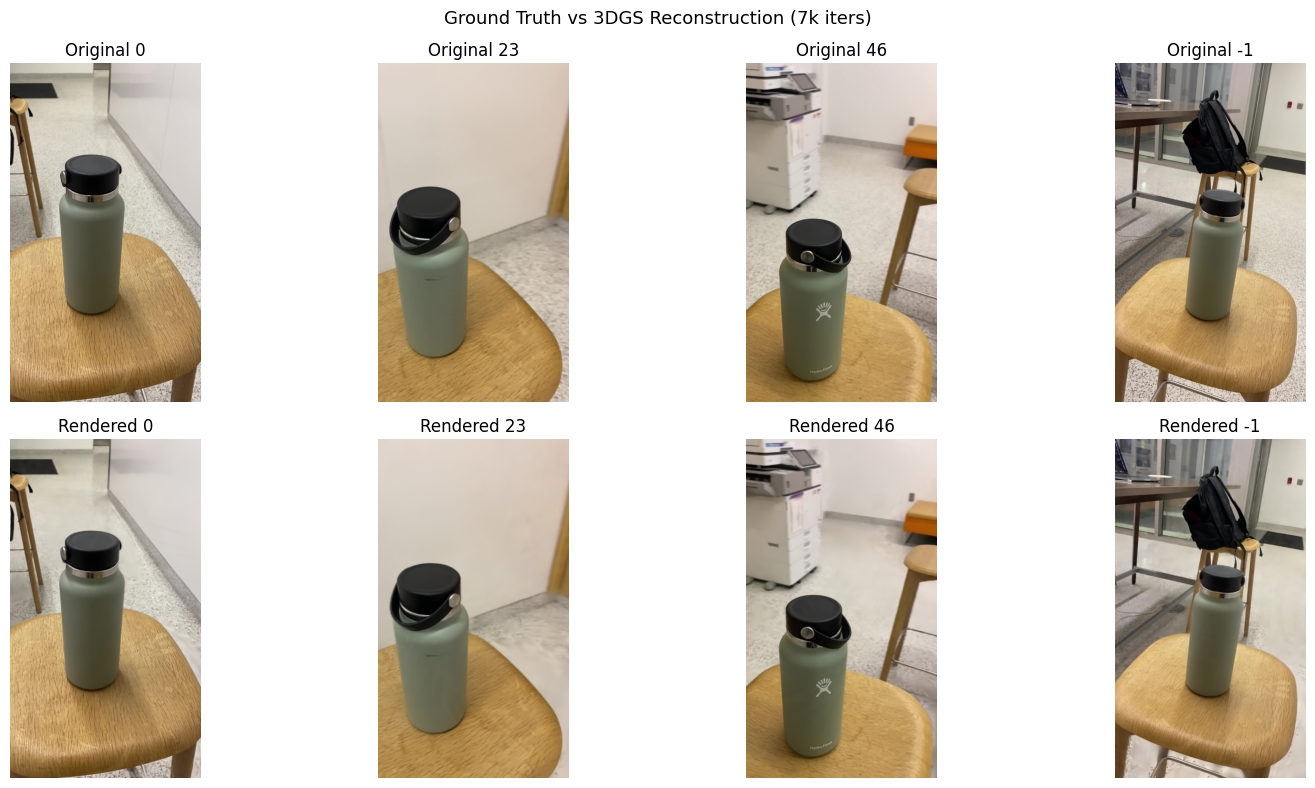

In [ ]:
# Cell 17 — Compare render vs original
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

render_dir = "/content/gs_output/train/ours_7000/renders"
gt_dir     = "/content/gs_output/train/ours_7000/gt"

renders = sorted(os.listdir(render_dir))
gts     = sorted(os.listdir(gt_dir))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = [0, len(renders)//3, 2*len(renders)//3, -1]

for col, i in enumerate(indices):
    axes[0, col].imshow(mpimg.imread(f"{gt_dir}/{gts[i]}"))
    axes[0, col].set_title(f"Original {i}")
    axes[0, col].axis("off")
    axes[1, col].imshow(mpimg.imread(f"{render_dir}/{renders[i]}"))
    axes[1, col].set_title(f"Rendered {i}")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("3DGS Render", fontsize=12)
plt.suptitle("Ground Truth vs 3DGS Reconstruction (7k iters)", fontsize=13)
plt.tight_layout()
plt.show()


### Download segment anything model for object masking

In [40]:
# Cell 18 — Install Segment Anything Model (SAM)
import os
os.chdir("/content")

!pip install -q segment-anything
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

print("SAM installed:", os.path.exists("sam_vit_b_01ec64.pth"))


SAM installed: True


In [41]:
# Cell 19 — Generate object masks with SAM
import numpy as np
import torch
import cv2
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import matplotlib.pyplot as plt

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b_01ec64.pth")
sam.to("cuda")
mask_generator = SamAutomaticMaskGenerator(sam)

# Output dir for masked images
masked_dir = "/content/frames_masked"
os.makedirs(masked_dir, exist_ok=True)

image_dir = "/content/colmap_undistorted/images"
frames = sorted(os.listdir(image_dir))

for fname in frames:
    img_bgr = cv2.imread(f"{image_dir}/{fname}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    cx, cy = w // 2, h // 2

    masks = mask_generator.generate(img_rgb)

    # Pick mask whose center is closest to image center
    best_mask = min(masks, key=lambda m: (
        (m["bbox"][0] + m["bbox"][2]/2 - cx)**2 +
        (m["bbox"][1] + m["bbox"][3]/2 - cy)**2
    ))

    # Apply mask — white background
    mask = best_mask["segmentation"].astype(np.uint8)
    masked = img_rgb.copy()
    masked[mask == 0] = 255

    cv2.imwrite(f"{masked_dir}/{fname}", cv2.cvtColor(masked, cv2.COLOR_RGB2BGR))

print(f"Masked {len(frames)} frames → {masked_dir}")


Masked 70 frames → /content/frames_masked
